In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets"



# Use recursive search inside all subdirectories and  **/ for a recursive search:
csv_file = glob.glob(os.path.join(base_path, "**/*data.csv"), recursive=True)

print(csv_file)

for i in csv_file:
    print(i)

['/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv', '/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv']
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/price_data.csv
/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/features_data.csv


In [2]:
# Select the 2 specific files
selected_files = [
    "price_data.csv",
    "features_data.csv",
    ]

# Filter the files to get full paths
selected_paths = [f for f in csv_file if any(name in f for name in selected_files)]


# Read and merge the files
df_list = [pd.read_csv(file, parse_dates=["timestamp"], low_memory=False) for file in selected_paths]

# Merge DataFrames on 'timestamp
merged_df = pd.merge(df_list[0],df_list[1], on="timestamp",how='inner')



# Save to a new CSV file
#output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/final_merged.csv"
output_path = "/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")
print(merged_df)


Merged CSV saved to: /Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/final_merged.csv
                timestamp  energy_price  net_export  total_grid_load  \
0     2023-01-01 00:00:00         -5.17    12001.75         38346.00   
1     2023-01-01 01:00:00         -1.07    14244.25         37777.25   
2     2023-01-01 02:00:00         -1.47    13897.50         36939.75   
3     2023-01-01 03:00:00         -5.08    12277.25         35932.50   
4     2023-01-01 04:00:00         -4.49    12179.00         35486.25   
...                   ...           ...         ...              ...   
19051 2025-03-04 19:00:00        163.67    -2636.25         48580.25   
19052 2025-03-04 20:00:00        134.13    -2636.25         48580.25   
19053 2025-03-04 21:00:00        114.38    -2636.25         48580.25   
19054 2025-03-04 22:00:00        114.41    -2636.25         48580.25   
19055 2025-03-04 23:00:00        106.81    -2636.25         48580.25   

       residu

In [3]:
# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity

df = pd.read_csv(output_path, low_memory=False)
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25


In [4]:
df.columns.to_list()

['timestamp',
 'energy_price',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']

In [5]:
corr_df = df[['energy_price',
 'net_export',
 'total_grid_load',
 'residual_load',
 'hydro_pumped_storage',
 'biomass',
 'hydropower',
 'wind_offshore',
 'wind_onshore',
 'photovoltaics',
 'other_renewable',
 'lignite',
 'hard_coal',
 'fossil_gas',
 'other_conventional']]


corr_matrix = corr_df.corr()
print(corr_matrix)

                      energy_price  net_export  total_grid_load  residual_load  hydro_pumped_storage   biomass  hydropower  wind_offshore  wind_onshore  photovoltaics  other_renewable   lignite  hard_coal  fossil_gas  other_conventional
energy_price              1.000000   -0.423153         0.341123       0.817476             -0.128055  0.513711    0.021928      -0.228394     -0.387822      -0.357526         0.291150  0.674905   0.563529    0.651867            0.180669
net_export               -0.423153    1.000000         0.150004      -0.610264              0.145698  0.079474   -0.502305       0.480807      0.735400       0.127398         0.250942 -0.258664   0.106880   -0.210696           -0.003161
total_grid_load           0.341123    0.150004         1.000000       0.389860              0.041303  0.417897   -0.061876       0.130272      0.156148       0.200378         0.231373  0.374024   0.512027    0.548070            0.191061
residual_load             0.817476   -0.610264      

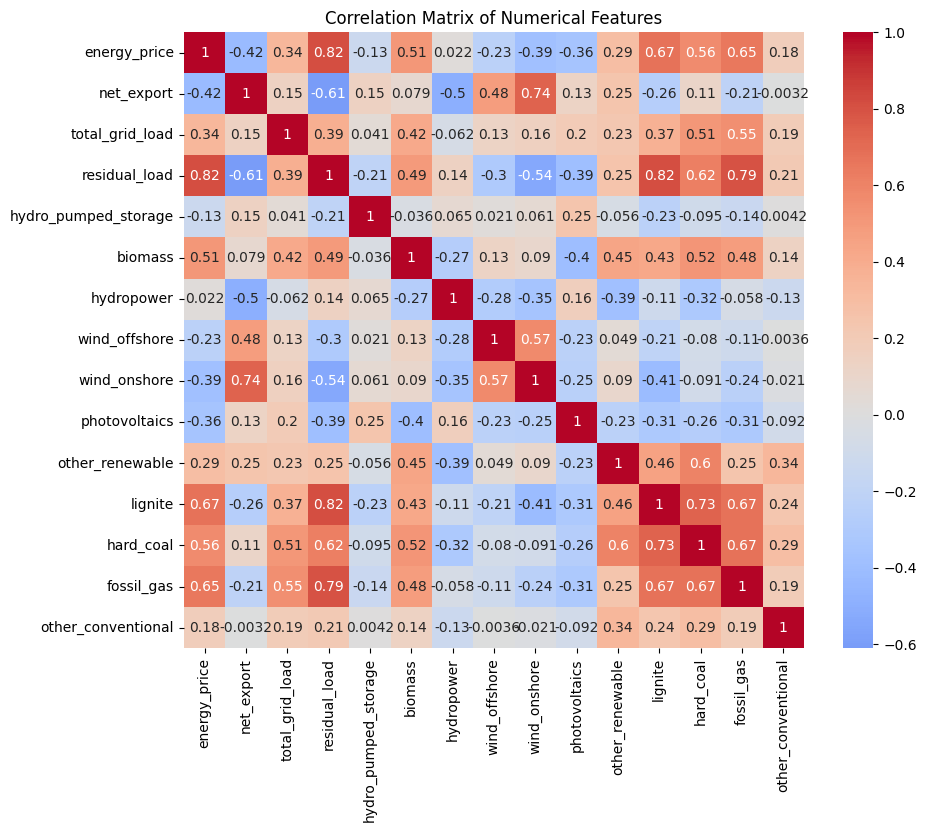

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Feature Enegineering

#### Temporal Features

In [7]:
# Now extract the hour
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month_of_year'] = df['timestamp'].dt.month
df['season'] = df['month_of_year'] % 12//3 # 0: Winter, 1: Spring, 2: Summer, 3: Fall


#### Energy Supply & Demand Features

In [8]:
df['renewable_ratio'] = (df['wind_offshore'] + df['wind_onshore'] + df['photovoltaics'] + df['other_renewable']) / df['total_grid_load']
df['fossil_ratio'] = (df['fossil_gas'] + df['lignite'] + df['hard_coal'] + df['other_conventional']) / df['total_grid_load']
df['wind_total'] = df['wind_offshore'] + df['wind_onshore']
df['solar_wind_ratio'] = df['photovoltaics'] / (df['wind_total'] + df['photovoltaics'])
df['grid_balance'] = df['total_grid_load'] - df['net_export']
df['conventional_vs_renewable'] = (df['lignite'] + df['hard_coal'] + df['fossil_gas']) / (df['biomass'] + df['hydropower'] + df['wind_total'] + df['photovoltaics'] + df['other_renewable'])



#### Volatility & Trend Features

In [9]:
df['rolling_mean_24h'] = df['total_grid_load'].rolling(window=24, min_periods=1).mean()
df['rolling_std_24h'] = df['total_grid_load'].rolling(window=24, min_periods=1).std()
df['change_in_load_1h'] = df['total_grid_load'].diff(1)
df['change_in_wind_1h'] = df['wind_total'].diff(1)
df['change_in_fossil_1h'] = df['fossil_ratio'].diff(1)

#### Lag & Lead Features

In [10]:
df['lag_wind_1h'] = df['wind_total'].shift(1)
df['lag_wind_24h'] = df['wind_total'].shift(24)
df['lag_demand_1h'] = df['total_grid_load'].shift(1)
df['lag_demand_24h'] = df['total_grid_load'].shift(24)
df['lead_demand_1h'] = df['total_grid_load'].shift(-1)
df['lead_demand_24h'] = df['total_grid_load'].shift(-24)

#### Interaction Features

In [11]:
df['wind_solar_interaction'] = df['wind_total'] * df['photovoltaics']
df['hydro_fossil_interaction'] = df['hydropower'] * df['fossil_ratio']
df['renewable_demand_ratio'] = df['renewable_ratio'] / df['total_grid_load']


#### Seasonality 

In [12]:
# Assuming 'date' column exists in your DataFrame
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Define seasons (adjust based on your region)
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['seasonality'] = df['timestamp'].apply(get_season)

#### Tracking Periods Where Energy Price Spikes 

In [13]:
season_mapping = {
    "Winter": 1,
    "Spring": 2,
    "Summer": 3,
    "Fall": 4
}

df["seasonality"] = df["seasonality"].map(season_mapping)

In [14]:
df['spike_indicator'] = (df['energy_price'] > 400).astype(int)

In [15]:
# Calculate mean and standard deviation of energy price
mean_price = df["energy_price"].mean()
std_price = df["energy_price"].std()

# Define a spike threshold (e.g., 1 standard deviation above mean)
spike_threshold = mean_price + std_price

# Create a new column to flag price spikes (True = spike, False = no spike)
df["price_spike_tool"] = df["energy_price"] > spike_threshold

# Display rows where spikes occurred
spikes = df[df["price_spike_tool"]]
print(spikes[["timestamp", "energy_price", "price_spike_tool"]])


                timestamp  energy_price  price_spike_tool
32    2023-01-02 08:00:00        145.98              True
33    2023-01-02 09:00:00        147.05              True
34    2023-01-02 10:00:00        145.61              True
35    2023-01-02 11:00:00        143.35              True
36    2023-01-02 12:00:00        144.38              True
...                   ...           ...               ...
19039 2025-03-04 07:00:00        169.61              True
19040 2025-03-04 08:00:00        141.95              True
19049 2025-03-04 17:00:00        148.61              True
19050 2025-03-04 18:00:00        180.92              True
19051 2025-03-04 19:00:00        163.67              True

[1973 rows x 3 columns]


In [16]:
df['rolling_mean_price_24h'] = df['energy_price'].rolling(window=24).mean()
df['price_spike'] = df['energy_price'] > df['rolling_mean_price_24h']

# Show only spikes
spikes = df[df['price_spike']]
print(spikes[['energy_price', 'rolling_mean_price_24h']])


       energy_price  rolling_mean_price_24h
23            35.00               14.913333
24            57.91               17.541667
25            51.67               19.739167
26            52.93               22.005833
27            44.09               24.054583
...             ...                     ...
19050        180.92              110.625417
19051        163.67              110.114583
19052        134.13              109.432917
19053        114.38              108.856667
19054        114.41              108.418333

[9024 rows x 2 columns]


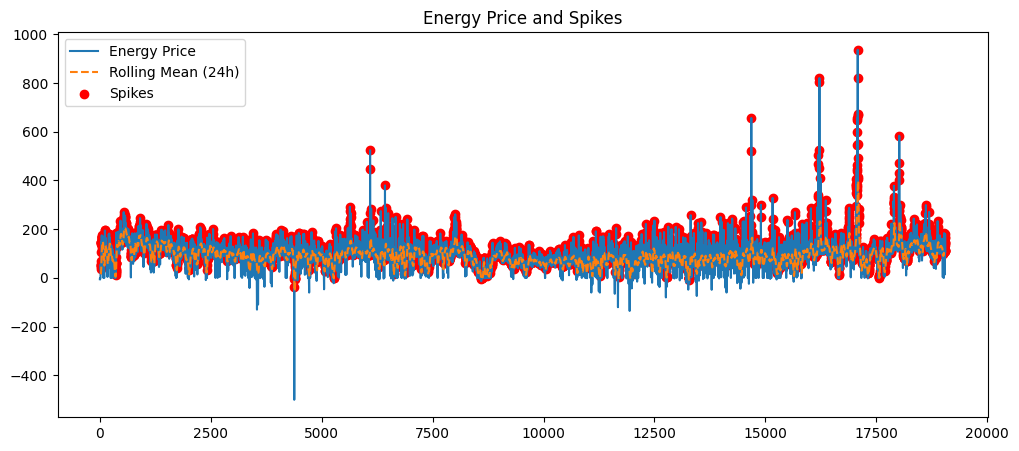

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['energy_price'], label='Energy Price')
plt.plot(df.index, df['rolling_mean_price_24h'], label='Rolling Mean (24h)', linestyle='dashed')
plt.scatter(df[df['price_spike']].index, df[df['price_spike']]['energy_price'], color='red', label='Spikes', marker='o')
plt.legend()
plt.title('Energy Price and Spikes')
plt.show()


In [18]:
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,price_spike_tool,rolling_mean_price_24h,price_spike
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37777.25,36789.75,39712.1875,298.418011,0.000022,1,0,False,NaN,False
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75,1121.25,-0.001063,31769.75,NaN,38346.00,NaN,36939.75,35423.75,32891.0000,285.706344,0.000023,1,0,False,NaN,False
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50,217.25,0.004544,32891.00,NaN,37777.25,NaN,35932.50,35284.25,41385.3125,290.329168,0.000024,1,0,False,NaN,False
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25,-2636.50,0.006664,33108.25,NaN,36939.75,NaN,35486.25,36058.50,30471.7500,298.659215,0.000024,1,0,False,NaN,False
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25,-570.75,0.002140,30471.75,NaN,35932.50,NaN,35647.25,37796.00,44851.5000,306.387967,0.000024,1,0,False,NaN,False


In [19]:
df.isna().sum()

timestamp                  0
energy_price               0
net_export                 0
total_grid_load            0
residual_load              0
                          ..
seasonality                0
spike_indicator            0
price_spike_tool           0
rolling_mean_price_24h    23
price_spike                0
Length: 46, dtype: int64

In [20]:
df.describe()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,rolling_mean_price_24h
count,19056,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19055.000000,19055.000000,19055.000000,19055.000000,19055.000000,19032.000000,19055.000000,19032.000000,19055.000000,19032.000000,1.905600e+04,19056.000000,1.905600e+04,19056.000000,19056.000000,19033.000000
mean,2024-02-02 00:02:16.020151296,89.488131,-1818.428638,53095.537744,30520.445568,1313.543943,4195.979232,1802.363180,2851.400071,13193.042808,6532.011007,118.070280,8595.075317,3957.131573,6596.093409,1293.794684,11.500000,2.997481,0.285894,6.127939,1.388119,0.426553,0.381619,16044.442879,0.228852,54913.966382,0.959348,53083.992272,6893.089210,0.537090,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,53096.311795,53110.618485,7.454405e+07,677.468137,8.253083e-06,2.388119,0.001627,89.528227
min,2023-01-01 00:00:00,-500.000000,-17359.000000,30902.750000,-8185.500000,43.625000,3214.750000,941.250000,0.250000,43.000000,0.250000,69.000000,2493.750000,309.250000,1606.250000,806.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.003095,0.116223,45.375000,0.000006,21723.250000,0.086560,36441.625000,402.166982,-16379.750000,-7066.000000,-0.121152,45.375000,45.375000,30902.750000,30902.750000,30902.750000,30902.750000,3.500000e+02,193.092116,4.690854e-08,1.000000,0.000000,-53.871250
25%,2023-07-18 12:45:00,64.717500,-7041.875000,45490.625000,20981.500000,662.500000,3977.187500,1463.750000,1140.750000,4918.125000,2.750000,97.000000,5553.062500,1873.000000,3823.937500,1192.250000,5.750000,1.000000,0.000000,3.000000,0.000000,0.226932,0.269705,6591.250000,0.000229,47217.125000,0.350955,49182.536458,5991.673365,-1532.625000,-649.125000,-0.011365,6590.500000,6585.875000,45490.250000,45482.812500,45491.000000,45517.812500,4.887005e+04,461.688855,4.333898e-06,1.000000,0.000000,66.787500
50%,2024-02-01 23:30:00,90.600000,-2401.000000,53123.750000,30596.000000,1166.312500,4210.500000,1808.250000,2669.125000,10308.625000,146.125000,109.000000,8581.625000,3121.375000,5843.875000,1315.000000,11.500000,3.000000,0.000000,6.000000,1.000000,0.407440,0.368190,13325.875000,0.011579,54609.375000,0.665040,53164.151042,7135.290540,-271.250000,-24.000000,0.000326,13325.000000,13334.750000,53124.750000,53119.000000,53124.750000,53138.375000,1.645532e+06,640.964080,7.645239e-06,2.000000,0.000000,90.289583
75%,2024-08-18 12:15:00,115.772500,2922.625000,60089.750000,39936.125000,1894.656250,4407.000000,2084.500000,4415.500000,19299.937500,10049.937500,134.000000,11247.000000,5446.812500,8471.812500,1392.250000,17.250000,5.000000,1.000000,9.000000,2.000000,0.602375,0.477459,23466.687500,0.451179,63041.000000,1.262683,57505.434896,7894.058886,1107.125000,609.375000,0.010562,23467.375000,23486.500000,60089.750000,60084.562500,60089.750000,60099.375000,9.210895e+07,846.704532,1.124744e-05,3.000000,0.000000,110.346250
max,2025-03-04 23:00:00,936.280000,18759.250000,76026.250000,69048.500000,3977.875000,5017.000000,3113.250000,7899.250000,48023.000000,46848.250000,203.750000,17173.250000,15240.500000,20146.500000,2252.500000,23.000000,6

In [21]:
# Save the updated dataset
#df.to_csv('enhanced_dataset.csv', index=False)
df.to_csv('/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/enhanced_dataset.csv', index=False)
print("Feature engineering complete. New dataset saved as 'enhanced_dataset.csv'")


Feature engineering complete. New dataset saved as 'enhanced_dataset.csv'
